# PRE-PROCESSING PER LA CLASSIFICAZIONE
Di seguito sarà eseguito il pre-processing per il dataset Crime_data.csv. Durante questa fase si filtreranno le feature più irrilevanti allo scopo della classificazione futura sull'arma usata. 

Sarà effettuata una procedura di encoding delle feature categoriche, utilizzando la tecnica del label encoding.

Si procedereà, successivamente, al salvataggio dei dataset intermedi e di encoding ottenuti.

In [ ]:
import pandas as pd

file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

import numpy as np

# ==========================
### Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
### Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)
# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
### Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
### Pulizia della colonna 'Location 1' 
### ed eliminazione 'Total Incidents'
# ==========================
def extract_lat_lon(location):
    if pd.isna(location) or location == 'Unknown':
        return np.nan, np.nan
    try:
        lat, lon = location.strip('()').split(',')
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

crime_data[['Latitude', 'Longitude']] = crime_data['Location 1'].apply(
    lambda loc: pd.Series(extract_lat_lon(loc))
)

crime_data = crime_data.drop(columns=['Location 1'])
crime_data = crime_data.drop(columns=['Post'])

#controllo il range di valori della colonna Total Incidents
print(crime_data['Total Incidents'].unique())

#la colonna Total Incidents ha tutti valori identici pari a 1, quindi rindondante
crime_data = crime_data.drop('Total Incidents', axis=1)


# ==========================
### Label Encoding delle variabili categoriche
# ==========================

from sklearn.preprocessing import LabelEncoder

le_crimecod = LabelEncoder()
crime_data['CrimeCode_encoded'] = le_crimecod.fit_transform(crime_data['CrimeCode'])

le_loc = LabelEncoder()
crime_data['Location_encoded'] = le_loc.fit_transform(crime_data['Location'])

le_desc = LabelEncoder()
crime_data['Description_encoded'] = le_desc.fit_transform(crime_data['Description'])

le_weapon = LabelEncoder()
crime_data['Weapon_encoded'] = le_weapon.fit_transform(crime_data['Weapon'])

le_dist = LabelEncoder()
crime_data['District_encoded'] = le_dist.fit_transform(crime_data['District'])

le_neig = LabelEncoder()
crime_data['Neighborhood_encoded'] = le_desc.fit_transform(crime_data['Neighborhood'])

le_dow = LabelEncoder()
crime_data['DayOfWeek_encoded'] = le_dow.fit_transform(crime_data['DayOfWeek'])

#label di Inside/Outside
crime_data['Inside/Outside'] = crime_data['Inside/Outside'].map({'I': 1, 'O': 0, 'Unknown': 3 })

# ==========================
### Salvataggio dataset con chiavi di encodings
### e dataset finale
# ==========================


#Creo un dataset degli encoding per fare inverse in futuro
encoding = pd.DataFrame(crime_data[['CrimeCode', 'CrimeCode_encoded', 
                                   'Location', 'Location_encoded', 
                                   'Description', 'Description_encoded',
                                   'Weapon', 'Weapon_encoded', 
                                   'District', 'District_encoded',
                                   'Neighborhood', 'Neighborhood_encoded',
                                   'DayOfWeek', 'DayOfWeek_encoded']])

encoding.to_csv('Encodings.csv', index=False)

#salvo tutto il dataset senza colonne categoriche originali (elimino le colonne categoriche)
#elimino anche il date-time, tranne quelli separati

crime_data = crime_data.drop(['CrimeCode', 'Location', 'Description', 'Weapon', 'District', 'Neighborhood', 'DayOfWeek',
                              'CrimeDate', 'CrimeTime', 'DateTime', 'Latitude', 'Longitude'], axis=1)

crime_data.to_csv('Crime_data_encoded.csv', index=False)



--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64
[1]


# Classificazione arma usata
Si procede di seguito con la preparazione e split finale per eseguire la classificazione dell'arma usata, dato un determinato episodio violento. 

Il classificatore dovrà prendere in input una lista di valori, quali la data dell'episodio, il luogo e la descrizione al fine di offrire in output la tipologia di arma utilizzata. Le classi di armi possibili sono: 
- HANDS
- KNIFE
- FIREARM
- OTHER

In [ ]:
import pandas as pd

file_path = 'Crime_data_encoded.csv'
file_path_encodings = 'Encodings.csv'

crime_data = pd.read_csv(file_path)
encodings = pd.read_csv(file_path_encodings)

Si procede a filtrare la colonna weapon, identificando ed eliminando tutte le righe dove 'Weapon' = 'Unknow', in quanto non rientra tra le classi utili alla classificazione.

Dopo di ciò si controlla l'effettivo filtraggio.

In [10]:
Codice_arma = encodings.loc[encodings['Weapon'] == 'Unknown', 'Weapon_encoded'].values[0]

print(f'L\' encoding per \'Unknown\' è: ', Codice_arma)

print('Numero nuovo di righe del dataset:', crime_data.shape[0])

crime_data_weapon = crime_data[crime_data['Weapon_encoded'] != Codice_arma]

print('Numero nuovo di righe del dataset:', crime_data_weapon.shape[0])

check = Codice_arma in crime_data_weapon['Weapon_encoded'].values

print(check)

L' encoding per 'Unknown' è:  4
Numero nuovo di righe del dataset: 281595
Numero nuovo di righe del dataset: 93184
False


# Feature selection
Tentiamo di filtrare ulteriormente le feature troppo correlate tra di loro. Usiamo una matrice di correlazione per vedere le correlazioni tra coppie di variabili (colonne del dataset) ed eliminamo quelle che superano la threshold di 0.85.

Questa operazione permette maggiore stabilità della predizione e, possibilmente, interpretabilità del risultato.

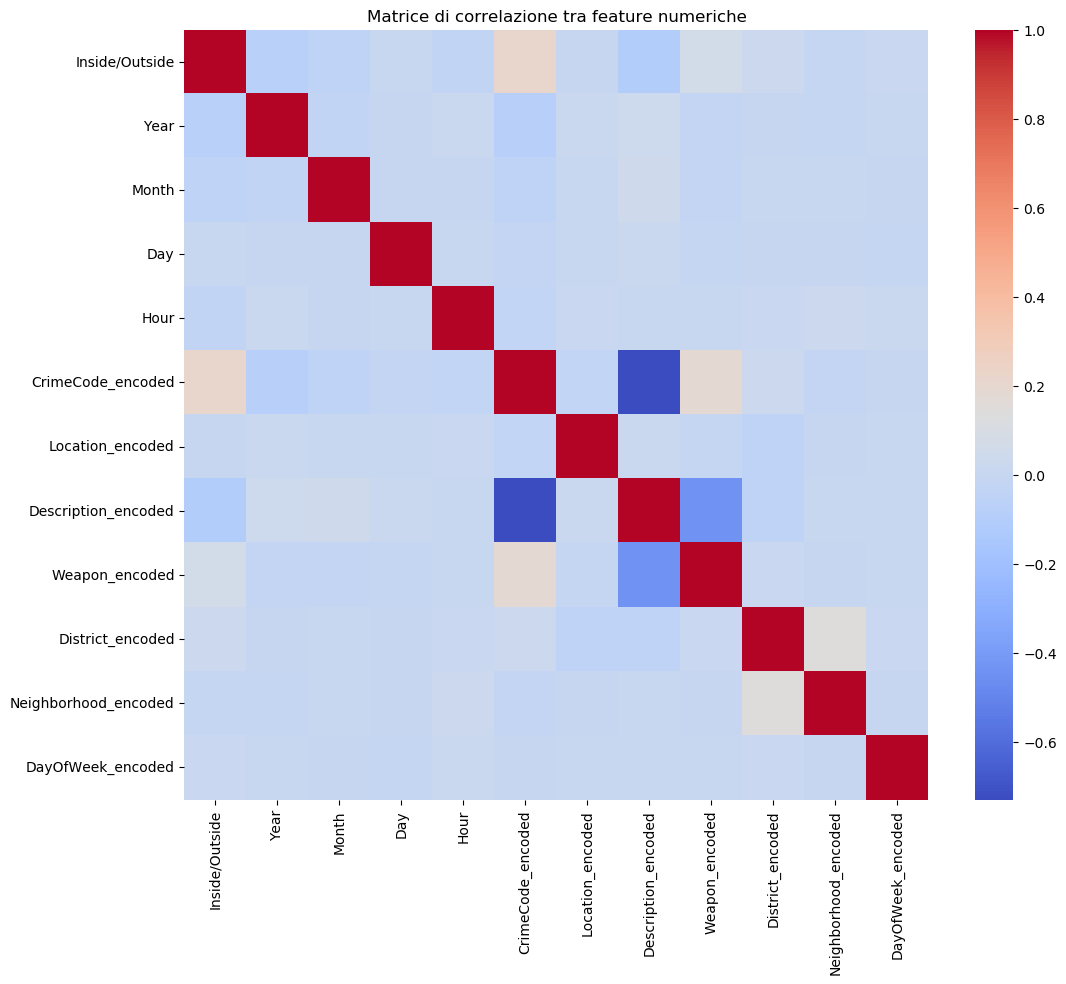

Non ci sono coppie di feature altamente correlate


In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = crime_data_weapon.corr(numeric_only=True)

# Visualizzazione come heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matrice di correlazione tra feature numeriche")
plt.show()

# Estrai tutte le coppie di correlazioni
corr_pairs = corr_matrix.unstack()

# Filtra le coppie fortemente correlate (escludendo la diagonale 1.0)
high_corr = corr_pairs[(abs(corr_pairs) > 0.85) & (abs(corr_pairs) < 1)]


# Ordina per valore di correlazione
high_corr = high_corr.sort_values(ascending=False)

if high_corr.size == 0:
    print("Non ci sono coppie di feature altamente correlate")
else:
    print("Coppie di feature fortemente correlate:\n", high_corr)

Ora suddividiamo il dataset finale in training 80% e testing 20%. La validazione sarà effettuata tramire la tecnica della K-fold con 4 split.

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV

X = crime_data_weapon.drop('Weapon_encoded', axis=1)
y = crime_data_weapon['Weapon_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Definiamo i classificatori utilizzati per la predizione dell'arma usata. Le tecniche impiegate sono le seguenti:
- Decision Tree
- Random Forest
- Ada Boost Classifier
- Gradient Boost Classifier
- Rete neurale MLP


🔹 Addestramento e ricerca iperparametri per DecisionTreeClassifier...
Migliori parametri trovati: {'max_depth': 15}


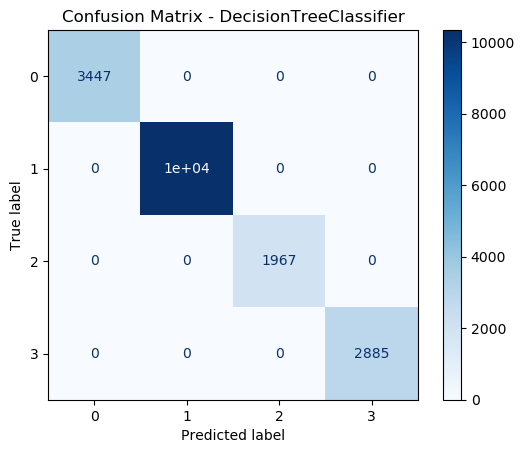

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3447
           1       1.00      1.00      1.00     10338
           2       1.00      1.00      1.00      1967
           3       1.00      1.00      1.00      2885

    accuracy                           1.00     18637
   macro avg       1.00      1.00      1.00     18637
weighted avg       1.00      1.00      1.00     18637



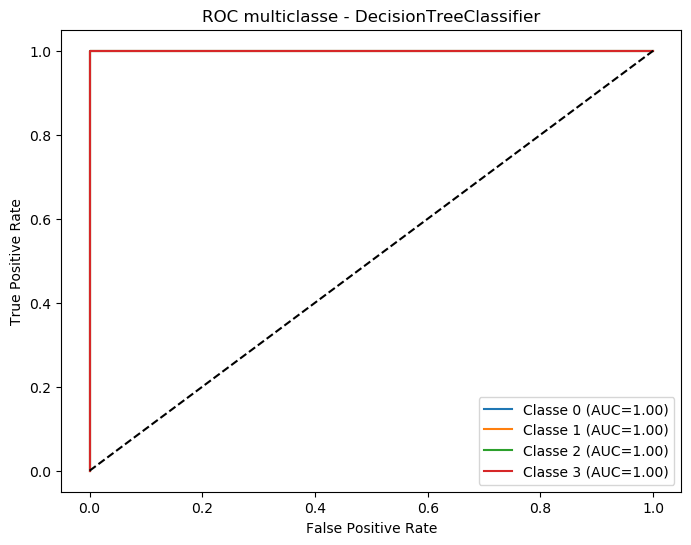

Cross-val accuracy media: 1.000

🔹 Addestramento e ricerca iperparametri per RandomForestClassifier...
Migliori parametri trovati: {'max_depth': 18, 'n_estimators': 30}


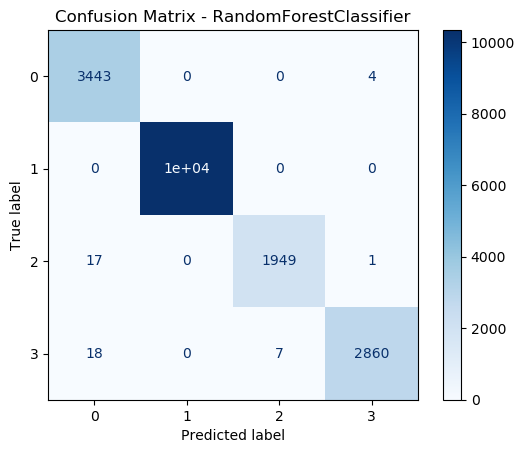

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3447
           1       1.00      1.00      1.00     10338
           2       1.00      0.99      0.99      1967
           3       1.00      0.99      0.99      2885

    accuracy                           1.00     18637
   macro avg       1.00      1.00      1.00     18637
weighted avg       1.00      1.00      1.00     18637



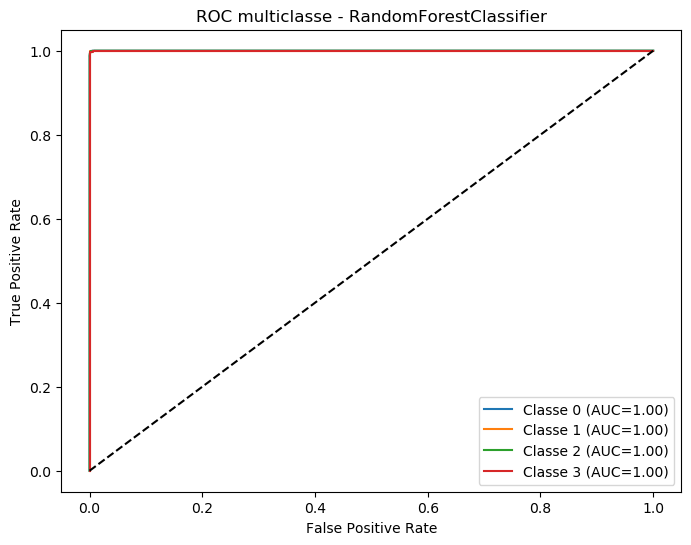

Cross-val accuracy media: 0.994

🔹 Addestramento e ricerca iperparametri per AdaBoostClassifier...


KeyboardInterrupt: 

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier 

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score

import numpy as np


classifiers = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42), {"max_depth": [10,13,15,18, 20, 23]}),
    ("RandomForestClassifier", RandomForestClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30], "max_depth": [10,13,15,18, 20, 23]}),
    ("AdaBoostClassifier", AdaBoostClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30]}),
    ("GradientBoostingClassifier", GradientBoostingClassifier(random_state=42), {"n_estimators": [5,15,25, 25, 30]}),
    ("NeuralNetwork", Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(64, 32, 16), 
            activation='relu',
            solver='adam',
            max_iter=100,
            random_state=42
        ))
    ]), {"clf__hidden_layer_sizes": [(64,32,16),(32,16,8)], "clf__max_iter": [100,200,300]})
]

results = {}

for name, model, param_grid in classifiers:
    print(f"\n🔹 Addestramento e ricerca iperparametri per {name}...")

    # GridSearchCV con cross-validation 4-fold
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=4,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    print(f"Migliori parametri trovati: {grid.best_params_}")

    # Predizioni sul test set
    y_pred = best_model.predict(X_test)

    # --- Confusion matrix ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # --- Metriche ---
    print(classification_report(y_test, y_pred))

    # --- ROC multiclasse ---
    if hasattr(best_model, "predict_proba"):
        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)
        y_proba = best_model.predict_proba(X_test)

        plt.figure(figsize=(8,6))
        for i, c in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Classe {c} (AUC={roc_auc:.2f})")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC multiclasse - {name}")
        plt.legend()
        plt.show()
    else:
        print("Nessuna probabilità per calcolare ROC.")

    # --- Plot loss rete neurale ---
    if name == "NeuralNetwork":
        clf = best_model.named_steps['clf']
        plt.figure(figsize=(6,4))
        plt.plot(clf.loss_curve_)
        plt.title("Rete neurale - Andamento del loss")
        plt.xlabel("Epoca")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

    # --- Salva metriche principali ---
    results[name] = {
        'best_model': best_model,
        'best_params': grid.best_params_,
        'accuracy': best_model.score(X_test, y_test),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'confusion_matrix': cm
    }

    # --- Cross-validation finale sul dataset intero ---
    cv_scores = cross_val_score(best_model, X, y, cv=5)
    print(f"Cross-val accuracy media: {cv_scores.mean():.3f}")